In [2]:
import numpy as np 
import matplotlib.pyplot as plt

# Odor 
- Makes a 1x3 array of binary numbers that are passed into an AL neuron

In [3]:
def make_odor(): 
    return np.random.randint(0,2, size=3) # generates a random array of size 2 with numbers 0-1 (excluding 2)

# Integrate and Fire Model
- LIF Model adapted from class
- Values from V_rest through C are set by parameters in paper

In [7]:
V_rest = -84.0      # Resting potential
V_thresh = -25.8    # Threshold for spiking
V_recov = -40.2     # Recovery threshold
V_spike = 9.5       # Spike potential
g_leak = 0.26       # Membrane conductance
C = 1.0             # Membrane capacitance (assumed)
I0 = 5            # Input current (can be adjusted)

V = np.full([10000,1],V_rest)  # Initialize V to be V_rest 
V[0] = V_rest                 # Set voltage to recovery state

dt = 0.01                     # Timestep in seconds 
t = np.arange(0,len(V))*dt    # Total duration

for k in range(1,len(V)-1): 
    dV = (-g_leak* (V[k]-V_rest) + I0)/C  # Based on equation in Integrate and Fire Model in Paper
    V[k+1] = V[k] + dt * dV                # Voltage in next time step is current voltage and change 

    if V[k] >= V_thresh: # Spikes if over threshold
        V[k] = V_spike   # Current voltage is spike potential
        V[k+1] = V_recov # Next voltage is recovery threshold

Plots

Text(0.5, 1.0, 'Drosophila Integrate-and-Fire Neuron (I=5 nA)')

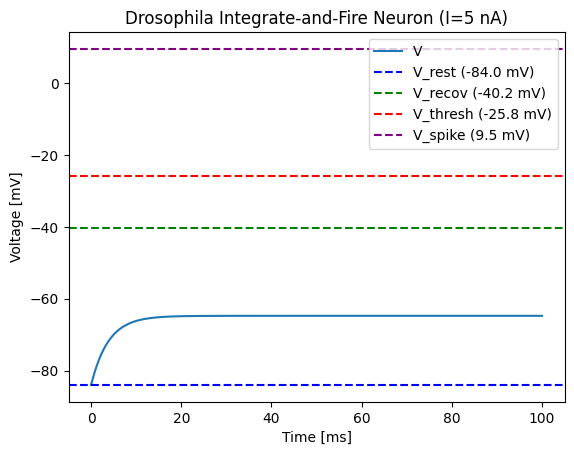

In [8]:
plt.figure()
plt.plot(t, V, label='V')
plt.axhline(y=V_rest,   color='b', linestyle='--', label=f'V_rest ({V_rest} mV)')
plt.axhline(y=V_recov,  color='g', linestyle='--', label=f'V_recov ({V_recov} mV)')
plt.axhline(y=V_thresh, color='r', linestyle='--', label=f'V_thresh ({V_thresh} mV)')
plt.axhline(y=V_spike,  color='purple', linestyle='--', label=f'V_spike ({V_spike} mV)')
plt.xlabel('Time [ms]')
plt.ylabel('Voltage [mV]')
plt.legend()
plt.title(f'Drosophila Integrate-and-Fire Neuron (I={I0} nA)')

# Testing

In [4]:
V[0] = V_rest